In [1]:
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader
import sys
sys.path.append("C:/Users/tjsss/OneDrive/Desktop/machine learning/mlFromScratch")
import torchvision
from torchvision import transforms
from utils.utilities import add_to_class, HyperParameters
from fashion_mnist_loader import FashionMNIST
from softmaxClassifier import Classifier
from sklearn.metrics import accuracy_score

## load mnist dataset

In [2]:
path = 'C:/Users/tjsss/OneDrive/Desktop/machine learning/mlFromScratch/fashionMNISTdataset'
data = FashionMNIST(path = path)

In [3]:
x,y = next(iter(data.get_data(True)))
print(x.shape, y.shape, x.dtype, y.dtype)

torch.Size([16, 1, 32, 32]) torch.Size([16]) torch.float32 torch.int64


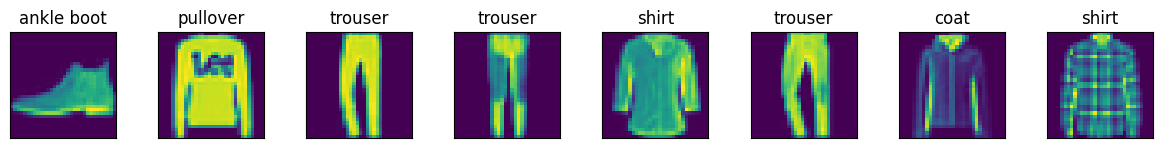

In [4]:
batch = next(iter(data.get_data(train=False)))
data.visualize(batch = batch)

In [5]:
train_loader = data.get_data(train=True, batch_size = 16)
val_loader = data.get_data(train = True, batch_size = 16)

In [6]:
softmax_reg = Classifier(32, 10)

In [7]:
softmax_reg.train(train_loader=train_loader, val_loader=val_loader, epochs = 10)

---------- 1 ----------
Mean Train Loss in Epoch: 1 is: 0.6907
Mean Val Loss in Epoch: 1 is: 0.5587
---------- 2 ----------
Mean Train Loss in Epoch: 2 is: 0.5294
Mean Val Loss in Epoch: 2 is: 0.5094
---------- 3 ----------
Mean Train Loss in Epoch: 3 is: 0.4947
Mean Val Loss in Epoch: 3 is: 0.4923
---------- 4 ----------
Mean Train Loss in Epoch: 4 is: 0.4758
Mean Val Loss in Epoch: 4 is: 0.4640
---------- 5 ----------
Mean Train Loss in Epoch: 5 is: 0.4630
Mean Val Loss in Epoch: 5 is: 0.4541
---------- 6 ----------
Mean Train Loss in Epoch: 6 is: 0.4543
Mean Val Loss in Epoch: 6 is: 0.4478
---------- 7 ----------
Mean Train Loss in Epoch: 7 is: 0.4477
Mean Val Loss in Epoch: 7 is: 0.4450
---------- 8 ----------
Mean Train Loss in Epoch: 8 is: 0.4423
Mean Val Loss in Epoch: 8 is: 0.4402
---------- 9 ----------
Mean Train Loss in Epoch: 9 is: 0.4379
Mean Val Loss in Epoch: 9 is: 0.4317
---------- 10 ----------
Mean Train Loss in Epoch: 10 is: 0.4339
Mean Val Loss in Epoch: 10 is: 0.42

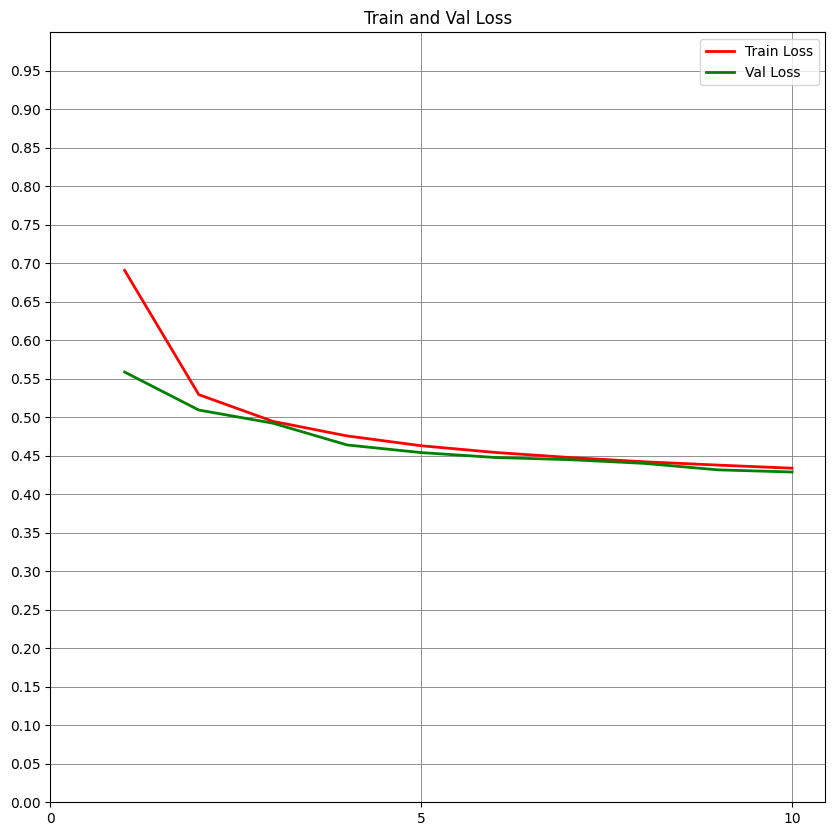

In [8]:
softmax_reg.history()

In [9]:
x,y = next(iter(val_loader))
data.text_labels(np.arange(10))

['t-shirt',
 'trouser',
 'pullover',
 'dress',
 'coat',
 'sandal',
 'shirt',
 'sneaker',
 'bag',
 'ankle boot']

In [25]:
['t-shirt'] == data.text_labels([y[1]])

True

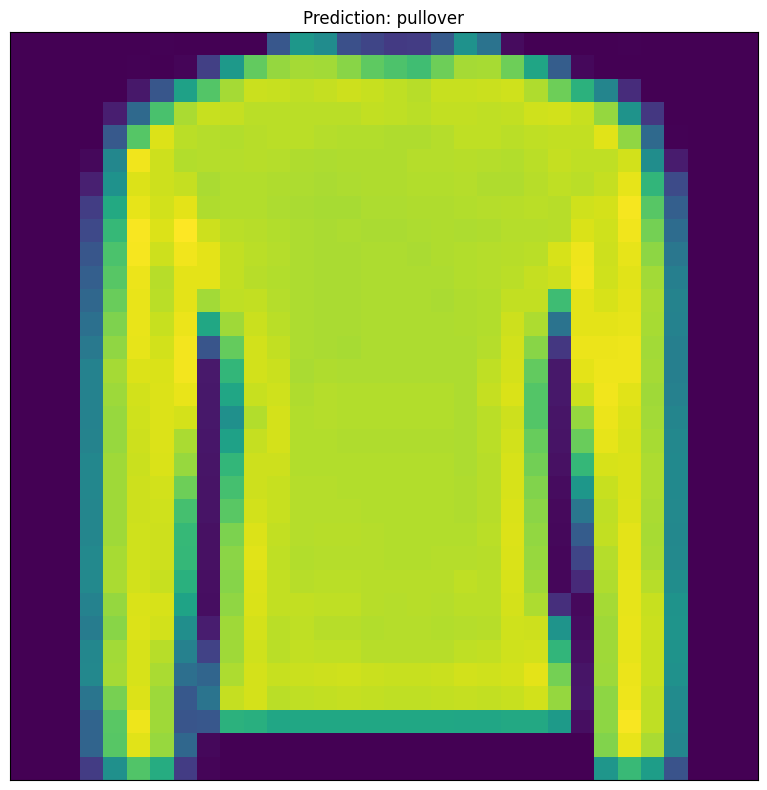

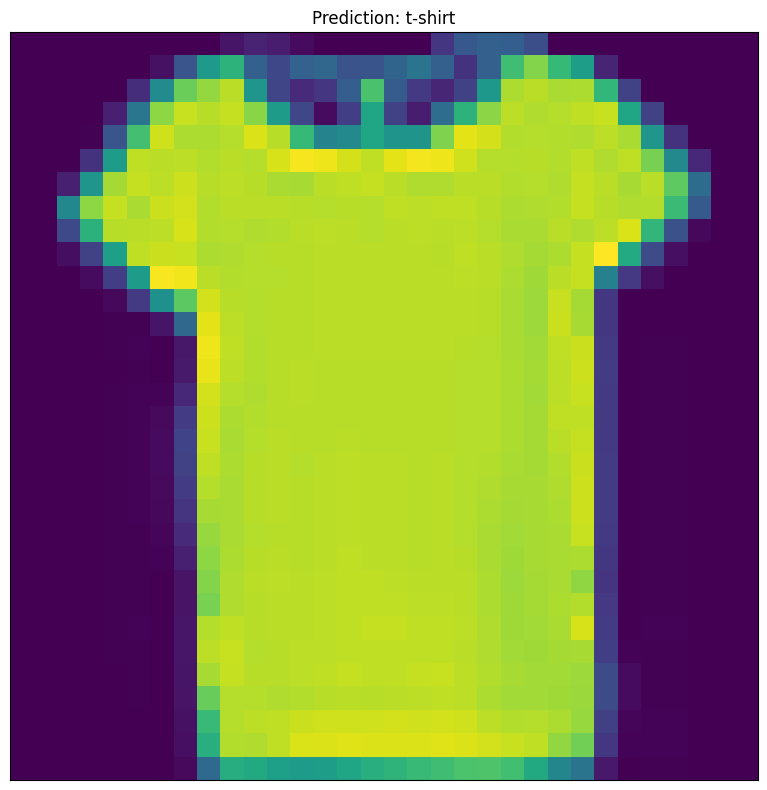

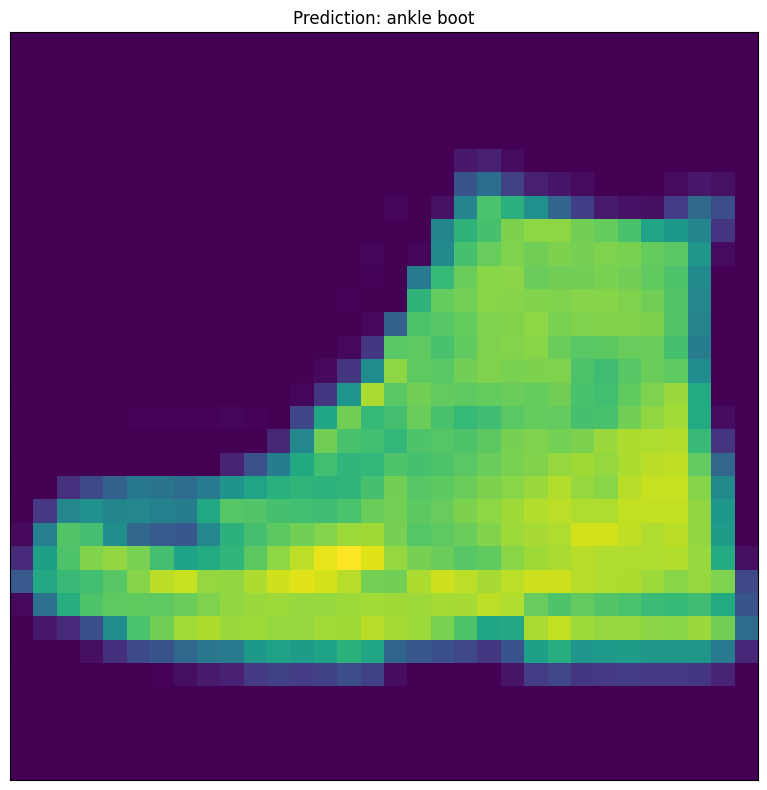

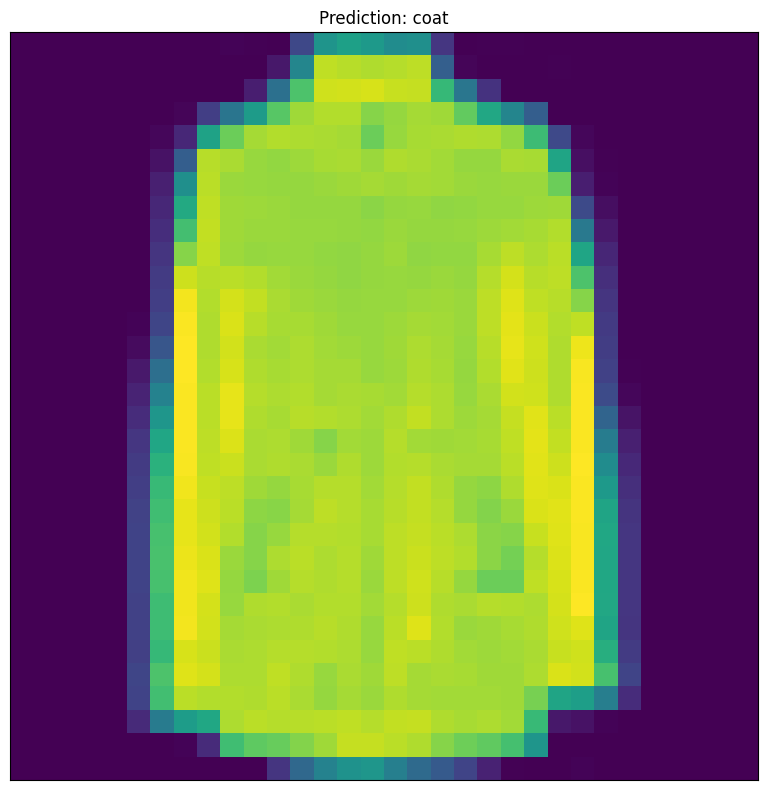

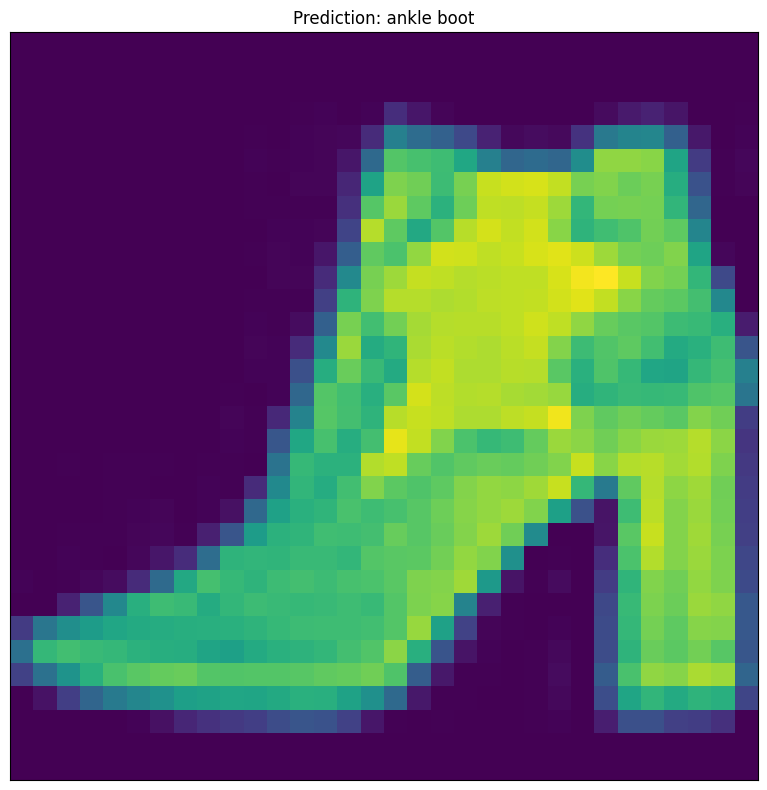

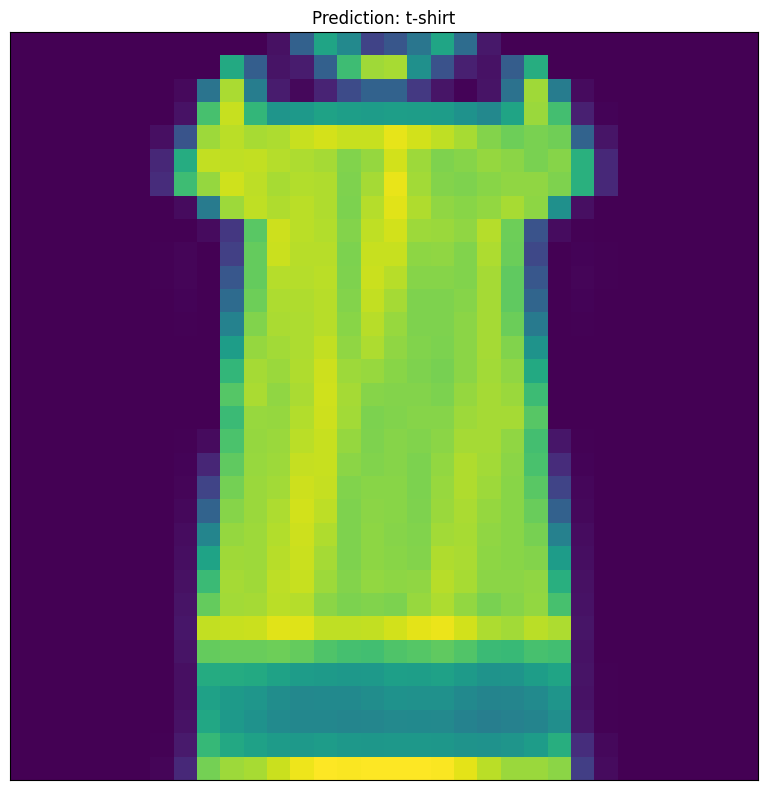

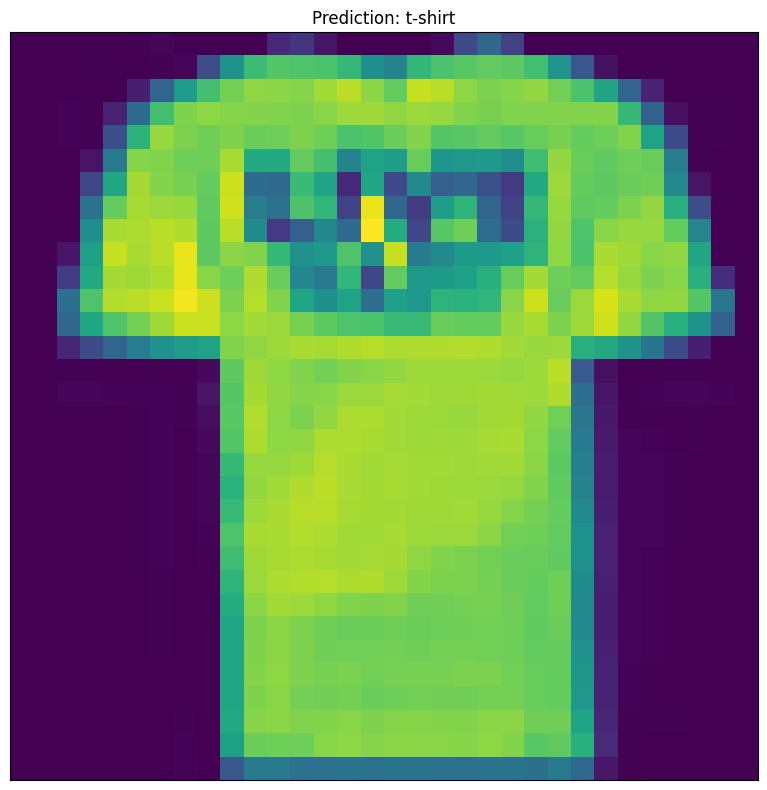

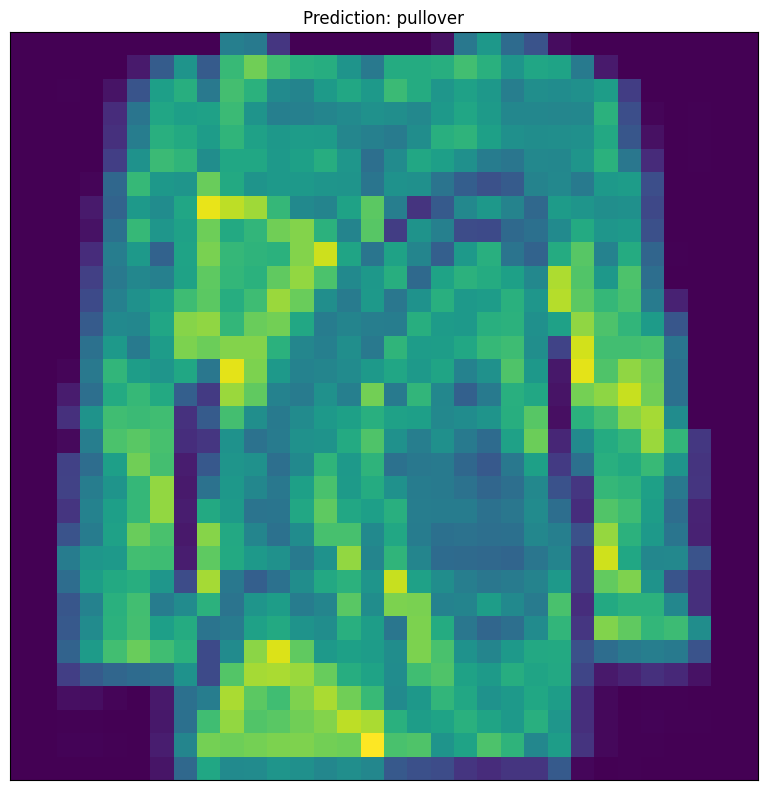

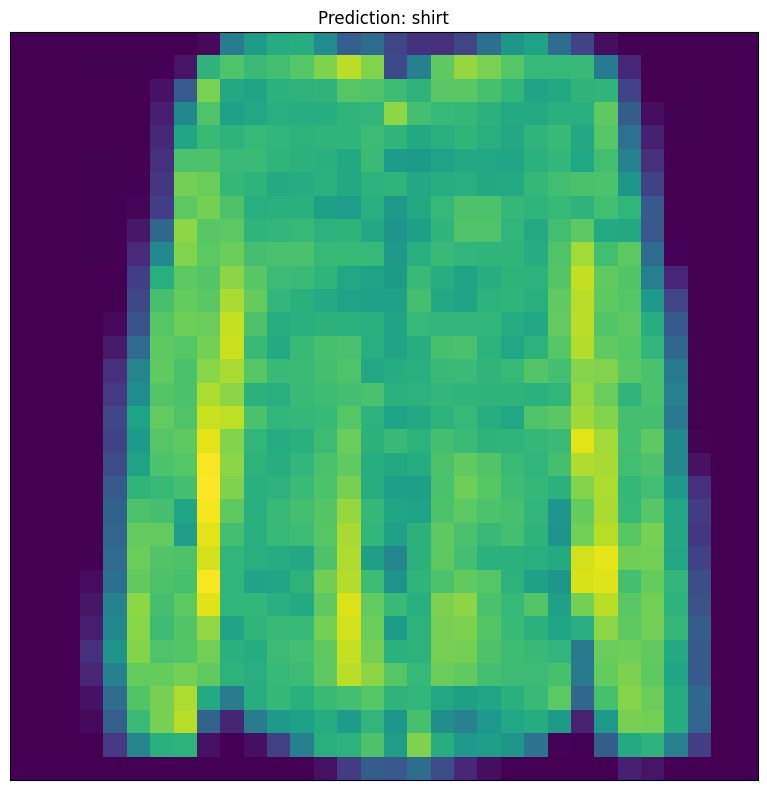

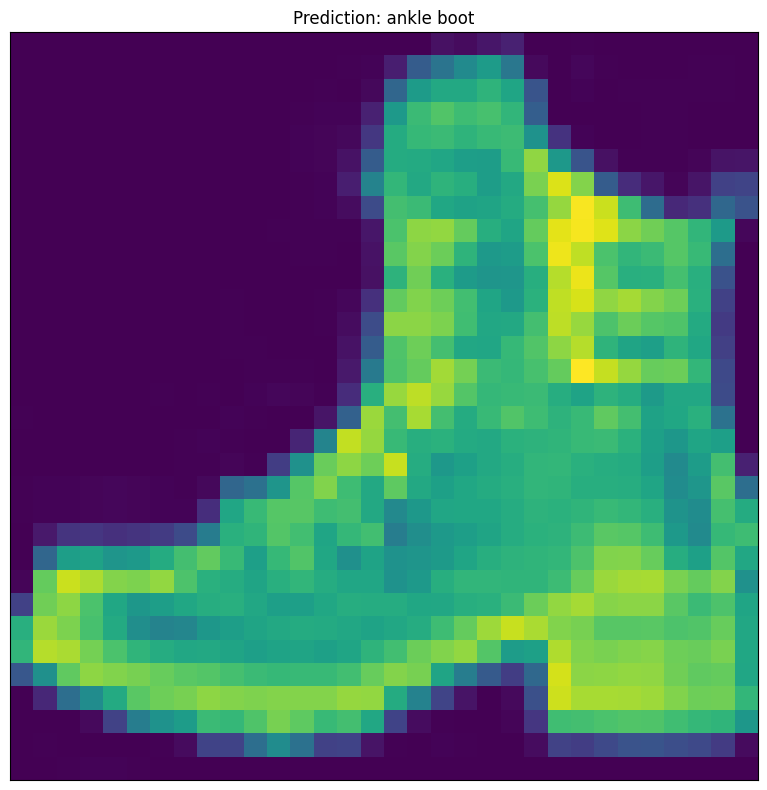

Accuracy:  80.0


In [27]:
n = 10
pred = [0]*n
score = 0
for i in range(n):
    pred[i] = softmax_reg.predict(x[i][0])
    truth = data.text_labels([y[i]])
    
    if [pred[i]] == truth:
        score += 1
        
print("Accuracy: ", (score/n)*100)
    
    

In [26]:
pred[0]

'pullover'